# Import librerie e setup variabili

Download dei dati da Yahoo Finance, con definizione di un intervallo di date e di una lista di titoli. I dati vengono organizzati in una lista di tuple (ticker, dataframe) per facilitare l'elaborazione successiva.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import datetime as dt
from IPython.display import display
from scipy import stats

start_date = dt.datetime(2016, 3, 31)
end_date = dt.datetime(2026, 3, 31)
stocks = ['MSFT', 'NVDA', 'TSLA', 'GM', 'XOM', 'NEE']
stock_list = []

data = yf.download(stocks, start=start_date, end=end_date)
for t in data.columns.get_level_values('Ticker').unique():
    ticker = data.xs(t, axis=1, level = 'Ticker', drop_level=True)
    stock_list.append((t, ticker))

data.head()

[*********************100%***********************]  6 of 6 completed


Price           Close                                                        \
Ticker             GM       MSFT        NEE      NVDA       TSLA        XOM   
Date                                                                          
2016-03-31  25.543200  48.491226  22.920944  0.872227  15.318000  53.705719   
2016-04-01  24.763014  48.789745  22.992607  0.884956  15.839333  53.300934   
2016-04-04  24.299772  48.666847  22.994545  0.876388  16.466000  53.429440   
2016-04-05  24.055965  47.902996  22.535509  0.875164  17.031334  52.819077   
2016-04-06  24.332281  48.394665  22.605230  0.876388  17.694668  53.525814   

Price            High                                  ...       Open  \
Ticker             GM       MSFT        NEE      NVDA  ...        NEE   
Date                                                   ...              
2016-03-31  25.673232  48.807302  23.010042  0.881284  ...  22.901576   
2016-04-01  25.356287  48.824866  23.046839  0.885446  ...  22.872521   
2016-04-04  24.771139  48.868784  23.083641  0.896952  ...  23.054588   
2016-04-05  24.161616  48.552705  23.029412  0.883243  ...  22.913200   
2016-04-06  24.340408  48.464905  22.611041  0.876878  ...  22.529692   

Price                                         Volume                     \
Ticker          NVDA       TSLA        XOM        GM      MSFT      NEE   
Date                                                                      
2016-03-31  0.879326  15.289333  54.014116  10209000  26360500  8025600   
2016-04-01  0.866841  16.322001  52.941141  17421700  24399200  8320800   
2016-04-04  0.892300  16.608000  53.365187  12167300  18928800  5239600   
2016-04-05  0.868555  16.033333  53.076073   9101900  19272300  8802800   
2016-04-06  0.864148  16.931334  53.127474   9620300  21188700  6557200   

Price                                       
Ticker           NVDA       TSLA       XOM  
Date                                        
2016-03-31  379884000  120193500  13896900  
2016-04-01  348292000  239962500  12235300  
2016-04-04  393940000  202129500   8050200  
2016-04-05  339568000  149230500  10446800  
2016-04-06  453376000  175582500   9320200  

[5 rows x 30 columns]

## Esportazione dei dati

Esportazione dei dati scaricati da Yahoo Finance in file CSV, uno per ogni titolo.

In [12]:
for t, df in stock_list:
    df.to_csv(f'./data/{t}.csv')

# Presentazione dei dati

Visualizzazione dei primi 5 record di ogni dataframe, insieme al nome del ticker. Visualizzato un grafico del prezzo di chiusura per ogni titolo.

'Ticker: GM'

Price,Close,High,Low,Open,Volume
Date,,,,,
2016-03-31,25.543200,25.673232,25.193738,25.201865,10209000
2016-04-01,24.763014,25.356287,24.641109,25.340033,17421700
2016-04-04,24.299772,24.771139,24.177867,24.706123,12167300
2016-04-05,24.055965,24.161616,23.852790,24.112854,9101900
2016-04-06,24.332281,24.340408,23.812151,24.104724,9620300
2016-04-07,23.909678,24.340410,23.714629,24.259139,12865600
2016-04-08,23.869040,24.185993,23.755260,24.112849,8843500


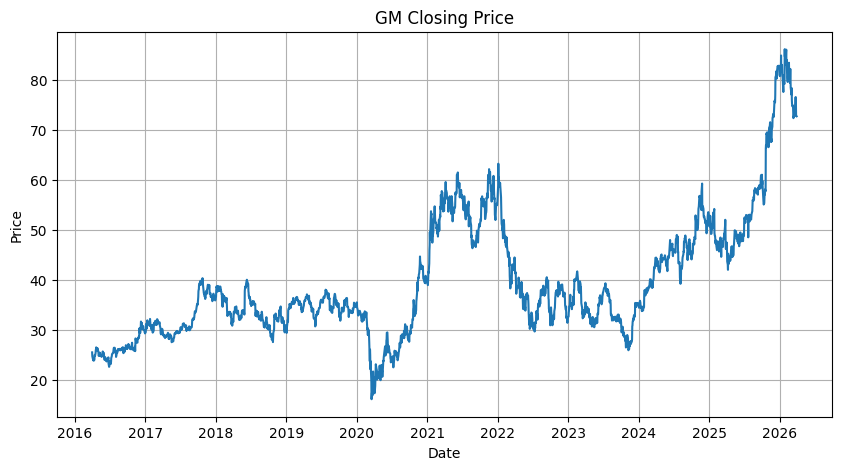

'Ticker: MSFT'

Price,Close,High,Low,Open,Volume
Date,,,,,
2016-03-31,48.491226,48.807302,48.166372,48.245391,26360500
2016-04-01,48.789745,48.824866,47.911758,48.333192,24399200
2016-04-04,48.666847,48.868784,48.289312,48.666847,18928800
2016-04-05,47.902996,48.552705,47.815195,48.456126,19272300
2016-04-06,48.394665,48.464905,47.595696,47.727396,21188700
2016-04-07,47.815193,48.210288,47.613256,48.175168,19225100
2016-04-08,47.780075,48.535145,47.692278,47.999572,22167200


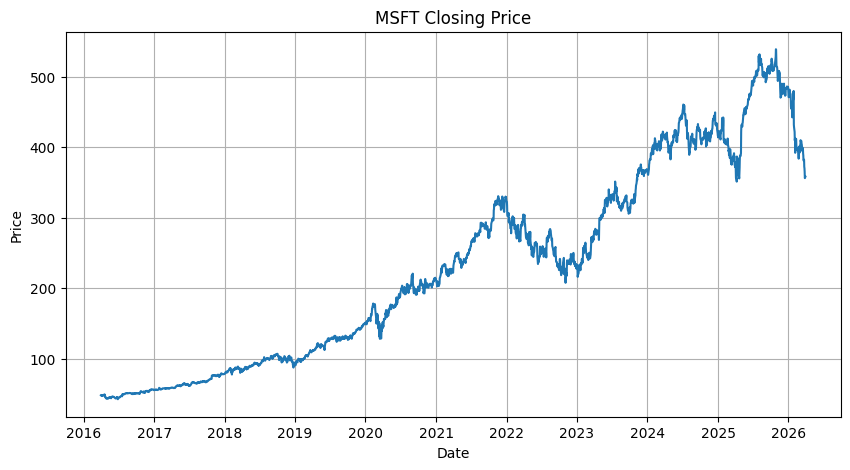

'Ticker: NEE'

Price,Close,High,Low,Open,Volume
Date,,,,,
2016-03-31,22.920944,23.010042,22.826038,22.901576,8025600
2016-04-01,22.992607,23.046839,22.750498,22.872521,8320800
2016-04-04,22.994545,23.083641,22.843469,23.054588,5239600
2016-04-05,22.535509,23.029412,22.496772,22.913200,8802800
2016-04-06,22.605230,22.611041,22.386364,22.529692,6557200
2016-04-07,22.504522,22.721451,22.465784,22.539386,5359600
2016-04-08,22.624603,22.746627,22.465780,22.465780,4268800


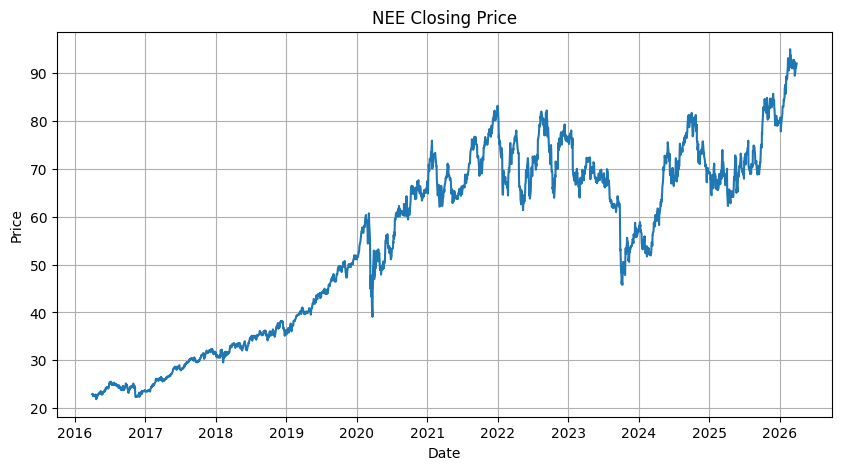

'Ticker: NVDA'

Price,Close,High,Low,Open,Volume
Date,,,,,
2016-03-31,0.872227,0.881284,0.865372,0.879326,379884000
2016-04-01,0.884956,0.885446,0.860231,0.866841,348292000
2016-04-04,0.876388,0.896952,0.872961,0.892300,393940000
2016-04-05,0.875164,0.883243,0.865128,0.868555,339568000
2016-04-06,0.876388,0.876878,0.847746,0.864148,453376000
2016-04-07,0.867331,0.878592,0.863659,0.870758,378104000
2016-04-08,0.872961,0.880061,0.864393,0.874430,255936000


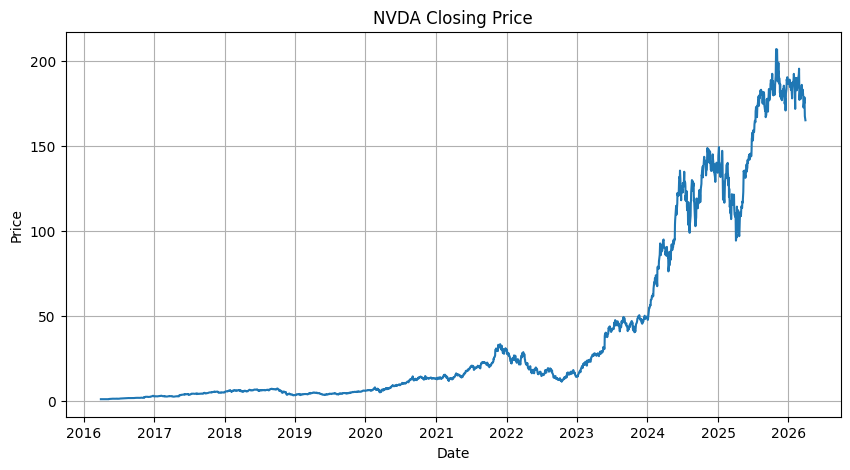

'Ticker: TSLA'

Price,Close,High,Low,Open,Volume
Date,,,,,
2016-03-31,15.318000,15.828000,15.000667,15.289333,120193500
2016-04-01,15.839333,16.526667,15.550000,16.322001,239962500
2016-04-04,16.466000,16.808001,16.242666,16.608000,202129500
2016-04-05,17.031334,17.104000,16.000000,16.033333,149230500
2016-04-06,17.694668,17.849333,16.896667,16.931334,175582500
2016-04-07,17.146667,17.955999,16.967333,17.763332,132843000
2016-04-08,16.671333,17.388000,16.534666,17.366667,110458500


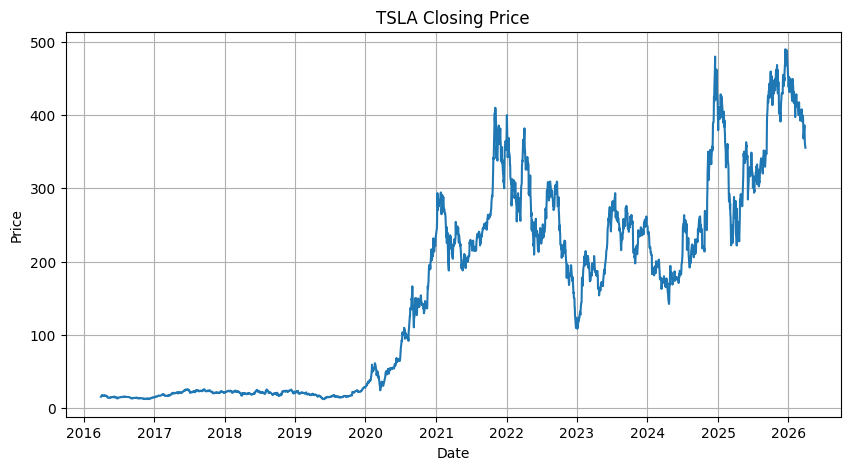

'Ticker: XOM'

Price,Close,High,Low,Open,Volume
Date,,,,,
2016-03-31,53.705719,54.675880,53.705719,54.014116,13896900
2016-04-01,53.300934,53.577205,52.934715,52.941141,12235300
2016-04-04,53.429440,53.904880,53.185290,53.365187,8050200
2016-04-05,52.819077,53.410166,52.677728,53.076073,10446800
2016-04-06,53.525814,53.622188,52.876903,53.127474,9320200
2016-04-07,52.921879,53.435868,52.716282,53.172449,8267100
2016-04-08,53.461575,53.615771,53.230278,53.519401,9376200


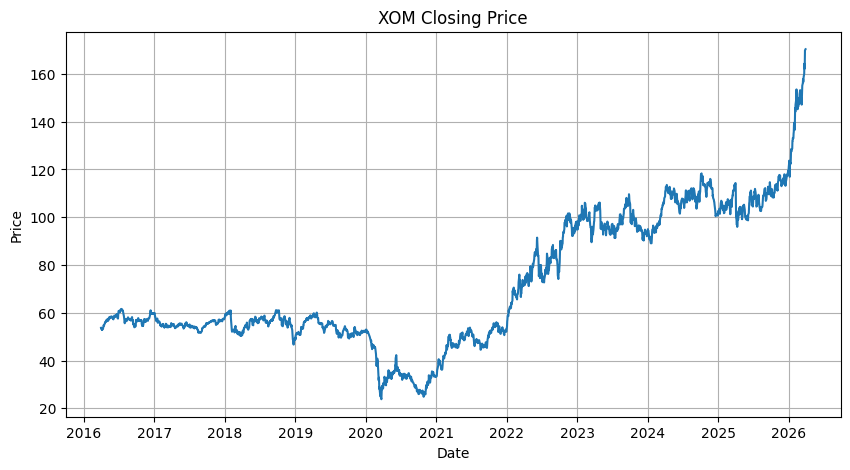

In [13]:
for name, stock in stock_list:
    display(f"Ticker: {name}", stock.head(7))
    plt.figure(figsize=(10, 5))
    plt.plot(stock['Close'])
    plt.title(f'{name} Closing Price')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.grid()
    # plt.savefig(f'./relazione/images/{name}_data_presentation.png')
    plt.show()

# Rendimenti

## Calcolo dei rendimenti semplici e logaritmici

Calcolo dei rendimenti semplici e logaritmici per ogni titolo e visualizzazione dei grafici.

Ticker: GM


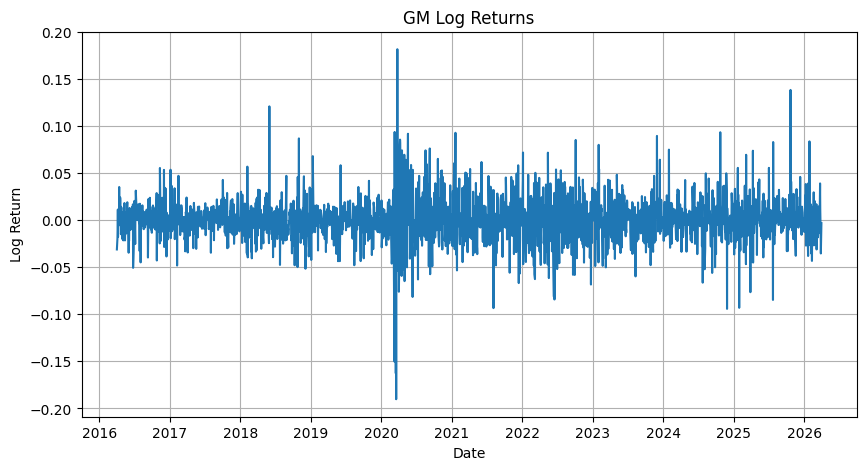

Ticker: MSFT


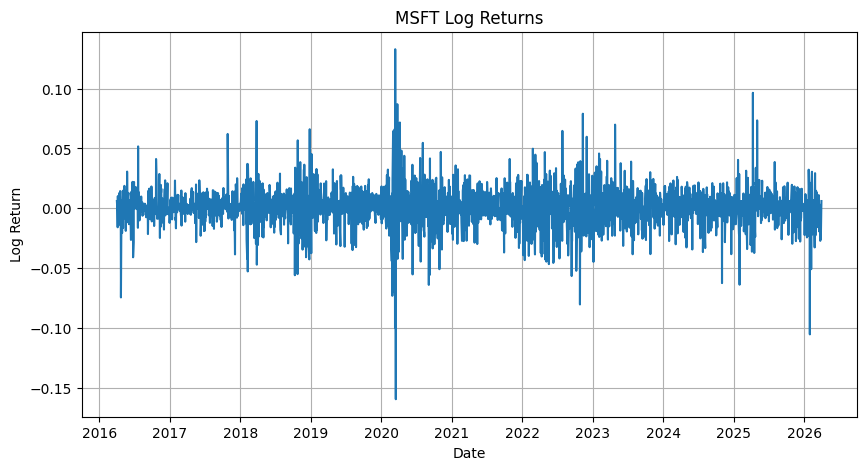

Ticker: NEE


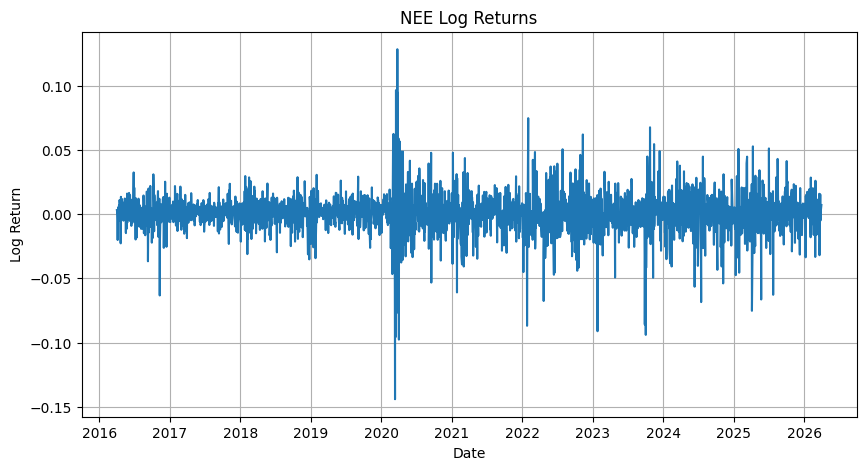

Ticker: NVDA


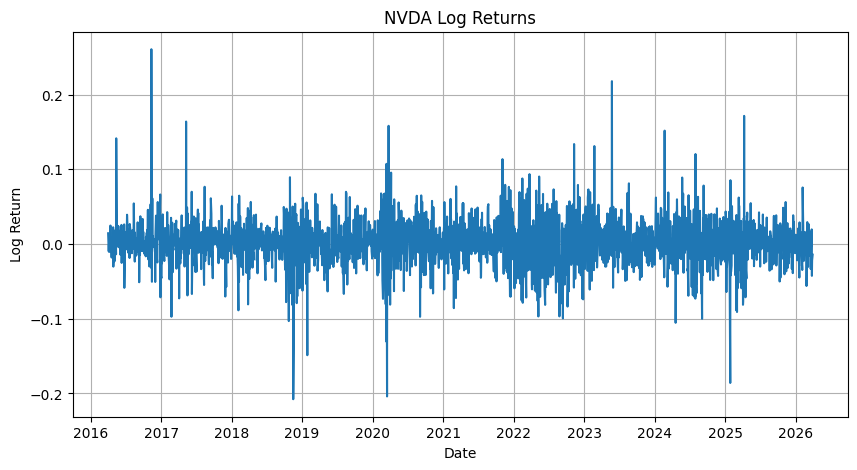

Ticker: TSLA


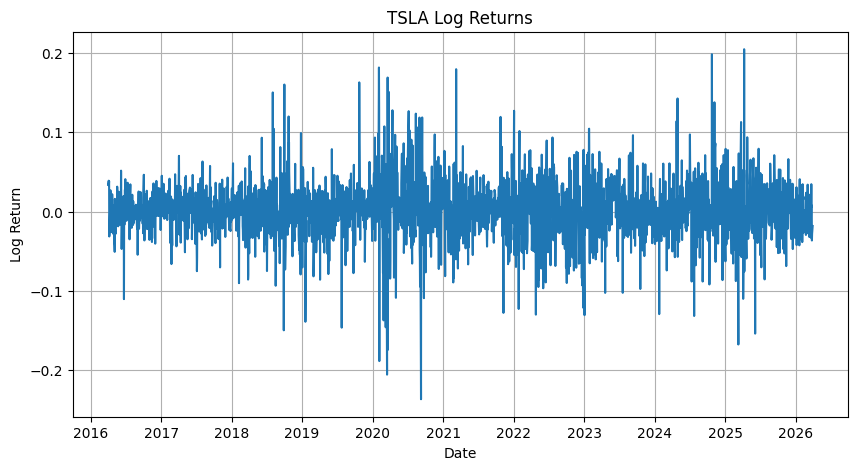

Ticker: XOM


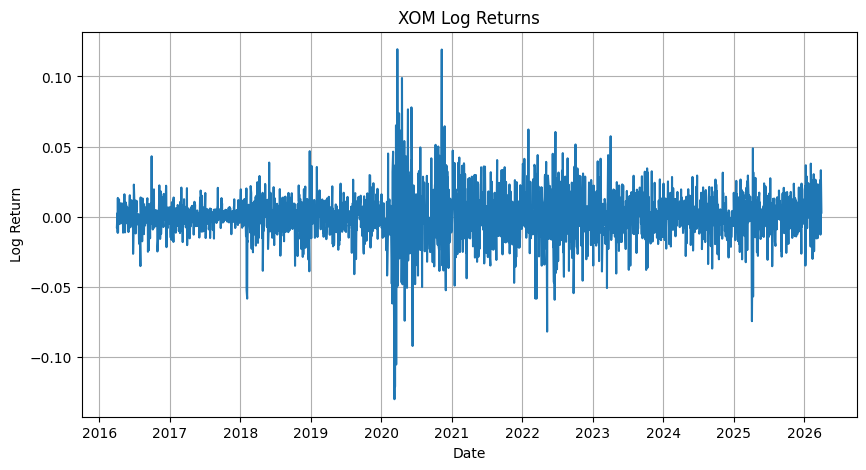

In [14]:
for ticker, df in stock_list:
    print(f"Ticker: {ticker}")
    df['Gross_SR'] = df['Close'] / df['Close'].shift(1)
    df['Net_SR'] = df['Gross_SR'] - 1
    df['LR'] = np.log(df['Gross_SR'])
    plt.figure(figsize=(10, 5))
    plt.plot(df['LR'])
    plt.title(f'{ticker} Log Returns')
    plt.xlabel('Date')
    plt.ylabel('Log Return')
    plt.grid()
    # plt.savefig(f'./relazione/images/{ticker}_log_returns.png')
    plt.show()
    plt.close()

## Calcolo dei rendimenti composti annui e cumulati

Calcolo dei rendimenti composti annui e rendimenti cumulati per ogni titolo.

In [15]:
delta = end_date - start_date
t = delta/dt.timedelta(days=1)
for ticker, df in stock_list:
    df["Cum"] = np.cumprod(df["Gross_SR"])
    cagr = (df['Close'].iloc[-1] / df['Close'].iloc[0]) ** (365 / t) - 1
    print(f'{ticker} CAGR: {cagr:.2%}')
    display(df.tail())

GM CAGR: 11.03%


Price,Close,High,Low,Open,Volume,Gross_SR,Net_SR,LR,Cum
Date,,,,,,,,,
2026-03-24,76.570000,76.870003,74.769997,74.980003,7122200,1.011226,0.011226,0.011163,2.997667
2026-03-25,76.610001,78.290001,76.389999,77.900002,7190700,1.000522,0.000522,0.000522,2.999233
2026-03-26,75.599998,77.169998,74.910004,75.970001,8470900,0.986816,-0.013184,-0.013271,2.959692
2026-03-27,72.980003,75.260002,72.680000,75.209999,7563200,0.965344,-0.034656,-0.035271,2.857121
2026-03-30,72.760002,74.230003,72.419998,73.709999,7192300,0.996985,-0.003015,-0.003019,2.848508


MSFT CAGR: 22.12%


Price,Close,High,Low,Open,Volume,Gross_SR,Net_SR,LR,Cum
Date,,,,,,,,,
2026-03-24,371.934418,381.643400,371.046357,381.533622,42733600,0.973211,-0.026789,-0.027154,7.670138
2026-03-25,370.238129,376.245107,368.831172,376.105426,31181200,0.995439,-0.004561,-0.004571,7.635157
2026-03-26,365.179077,373.910167,364.400764,370.018602,36836600,0.986336,-0.013664,-0.013759,7.530828
2026-03-27,355.998932,361.666679,355.739515,361.117850,37883400,0.974861,-0.025139,-0.025460,7.341512
2026-03-30,358.184204,364.570366,355.510003,361.117853,44797000,1.006138,0.006138,0.006120,7.386578


NEE CAGR: 14.91%


...

Price,Close,High,Low,Open,Volume,Gross_SR,Net_SR,LR,Cum
Date,,,,,,,,,
2026-03-24,175.199997,176.220001,173.979996,174.830002,147667800,0.997495,-0.002505,-0.002508,200.865204
2026-03-25,178.679993,181.220001,176.850006,177.100006,162602100,1.019863,0.019863,0.019668,204.854987
2026-03-26,171.240005,176.509995,171.139999,176.070007,186152200,0.958361,-0.041639,-0.042530,196.325110
2026-03-27,167.520004,170.970001,167.009995,170.000000,196212700,0.978276,-0.021724,-0.021963,192.060162
2026-03-30,165.169998,169.449997,164.270004,168.779999,185627000,0.985972,-0.014028,-0.014128,189.365901


TSLA CAGR: 36.92%


Price,Close,High,Low,Open,Volume,Gross_SR,Net_SR,LR,Cum
Date,,,,,,,,,
2026-03-24,383.029999,387.480011,376.309998,376.559998,60004900,1.005724,0.005724,0.005708,25.005223
2026-03-25,385.950012,396.230011,385.010010,389.989990,55157300,1.007623,0.007623,0.007595,25.195849
2026-03-26,372.109985,384.440002,371.869995,381.600006,55522900,0.964140,-0.035860,-0.036518,24.292335
2026-03-27,361.829987,369.859985,359.470001,369.690002,62065700,0.972374,-0.027626,-0.028015,23.621229
2026-03-30,355.279999,367.290009,352.140015,365.859985,67954400,0.981898,-0.018102,-0.018268,23.193629


XOM CAGR: 12.23%


Price,Close,High,Low,Open,Volume,Gross_SR,Net_SR,LR,Cum
Date,,,,,,,,,
2026-03-24,164.265060,166.350894,160.162899,160.619804,26131800,1.026376,0.026376,0.026034,3.058614
2026-03-25,162.159348,163.887622,161.831570,162.765236,17192300,0.987181,-0.012819,-0.012902,3.019406
2026-03-26,164.314713,164.563027,160.967437,162.983750,18625200,1.013292,0.013292,0.013204,3.059538
2026-03-27,169.837234,170.075607,163.688963,164.463704,30338300,1.033609,0.033609,0.033057,3.162368
2026-03-30,170.313995,175.220694,169.896829,171.346977,29813500,1.002807,0.002807,0.002803,3.171245


## Grafici diagnostici

Creazione di grafici diagnostici a 3 sezioni (istogramma e kernel density, boxplot, qq-plot) per
ciascuna serie di rendimenti

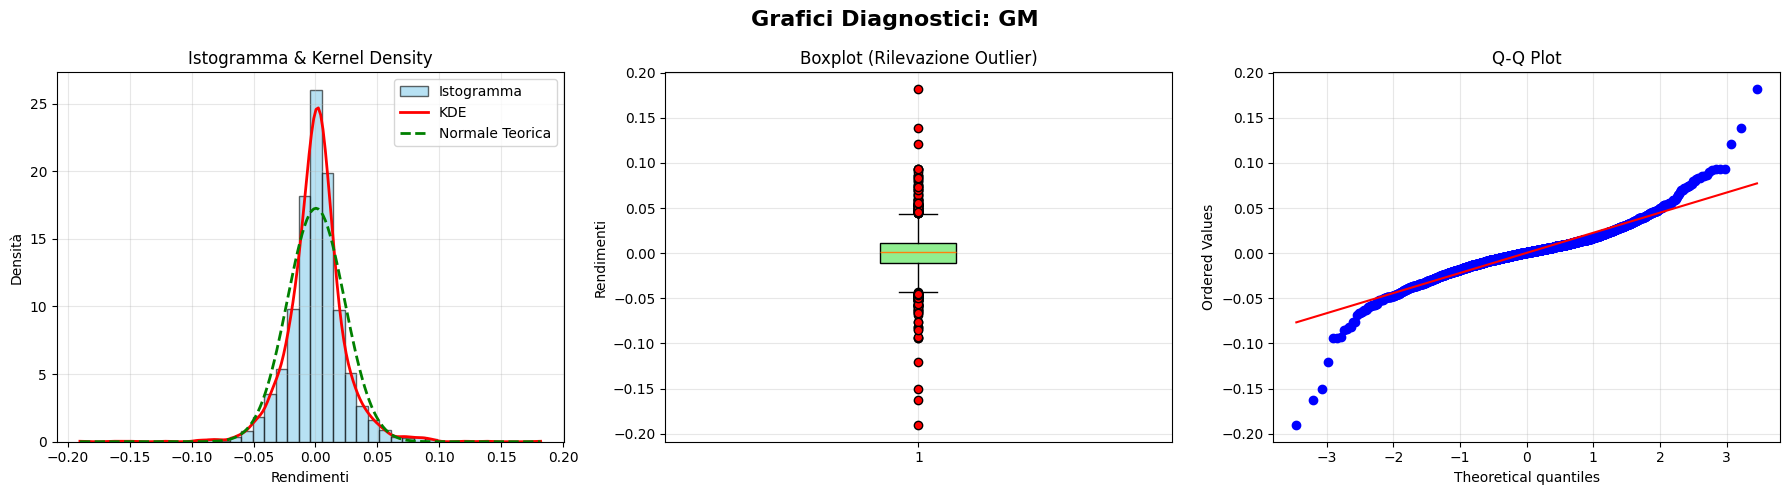

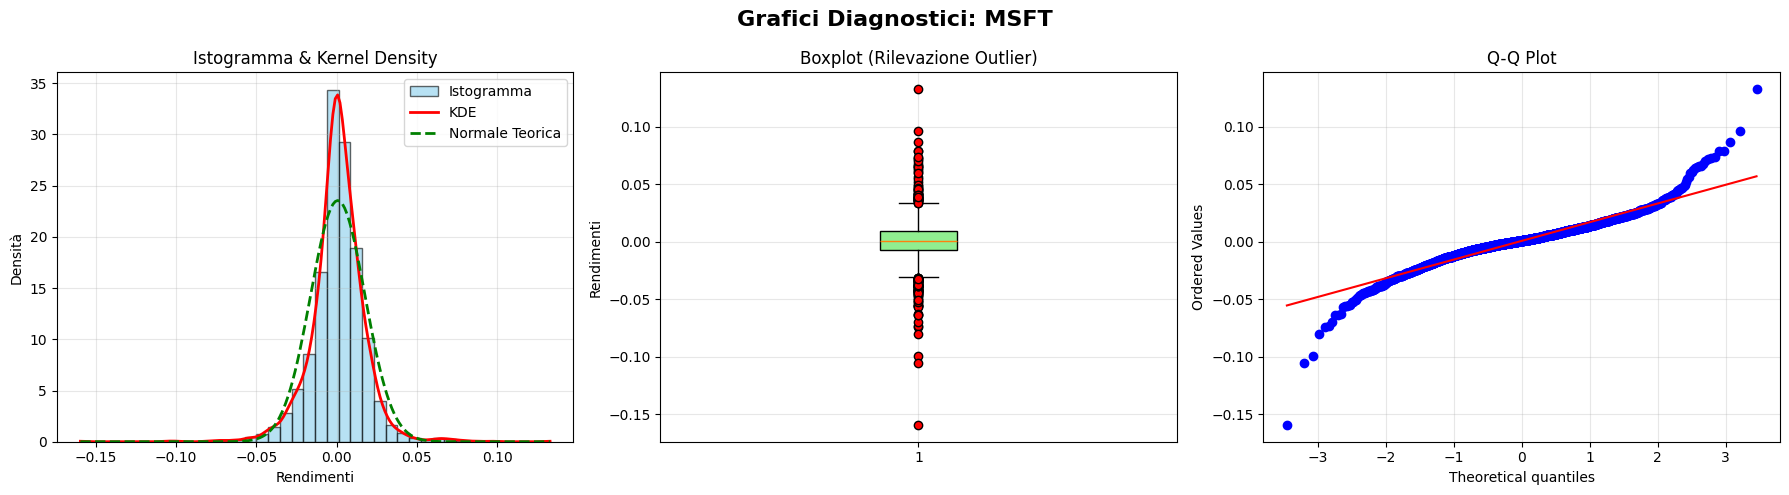

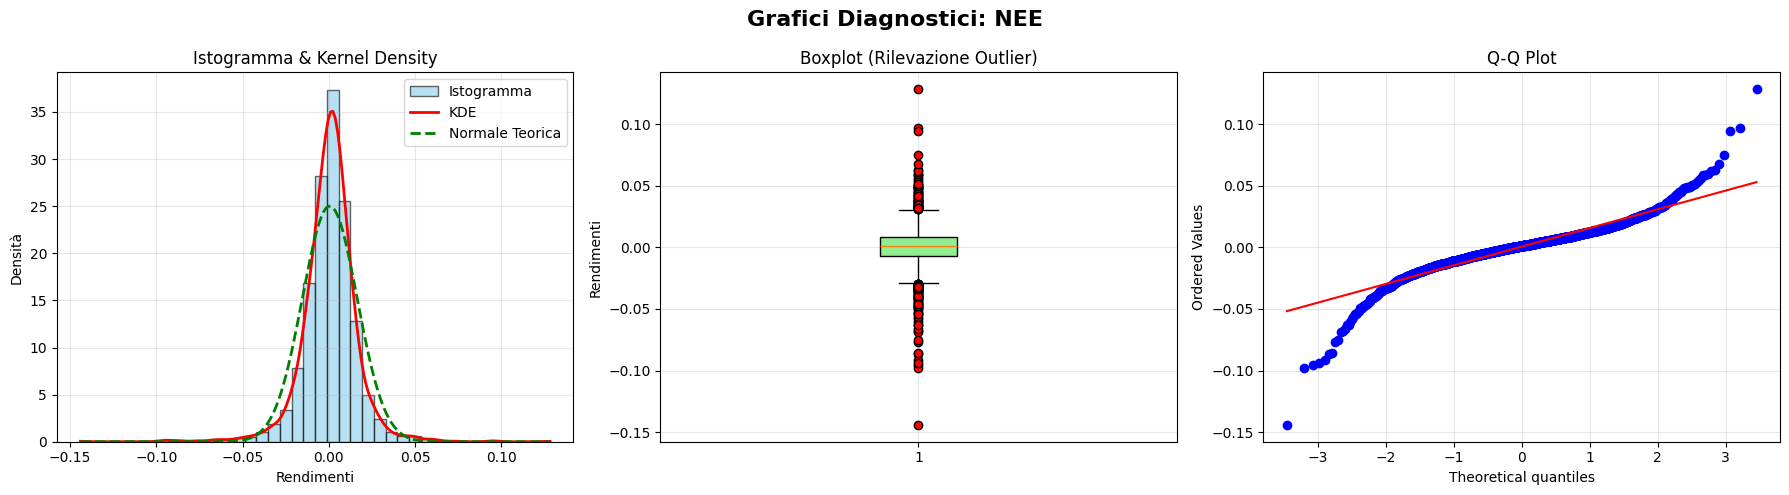

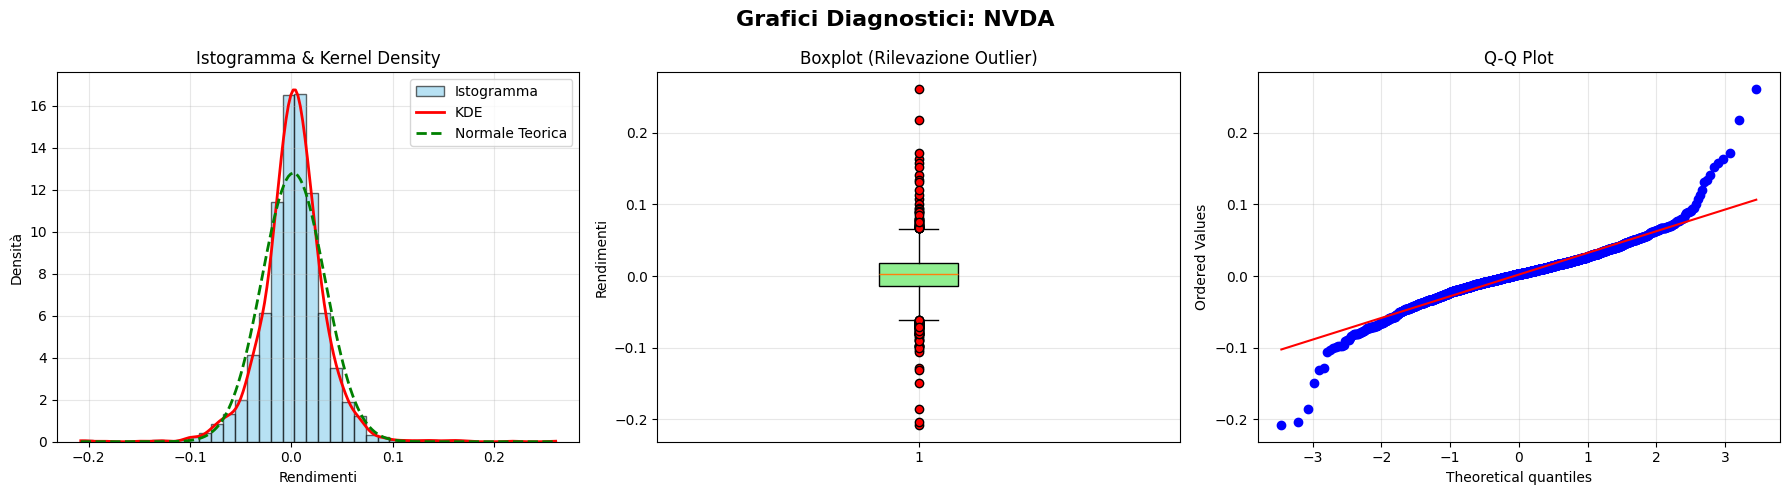

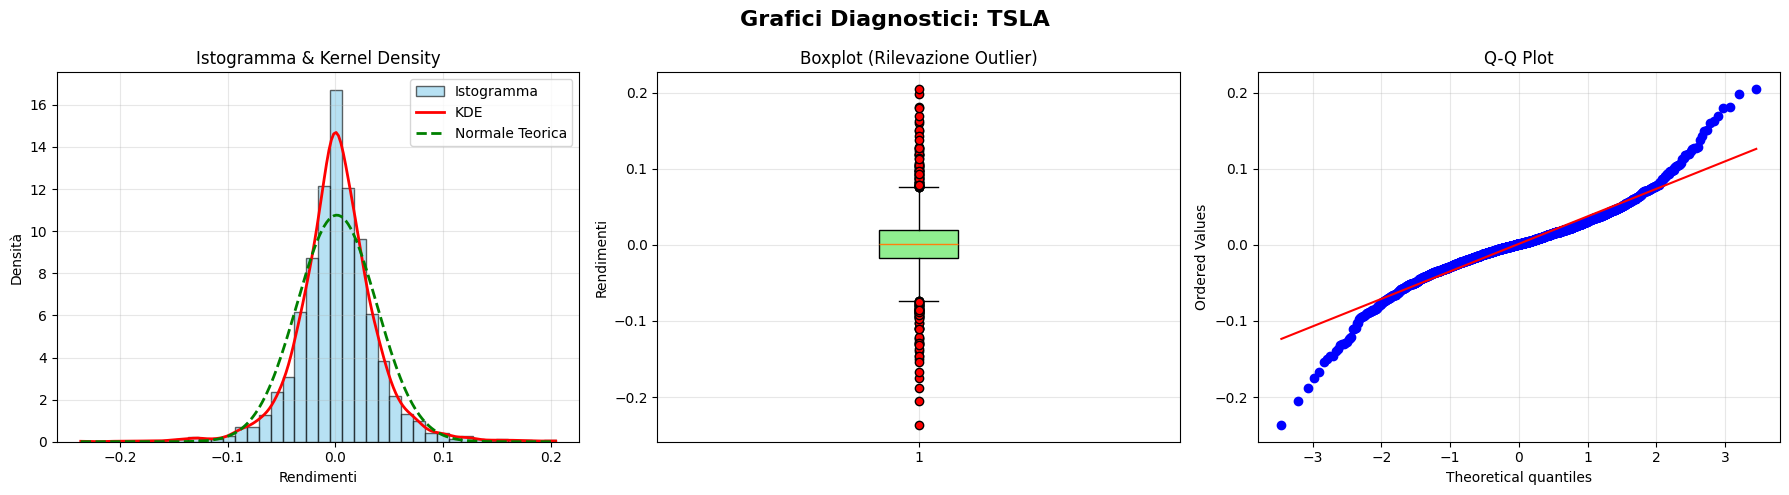

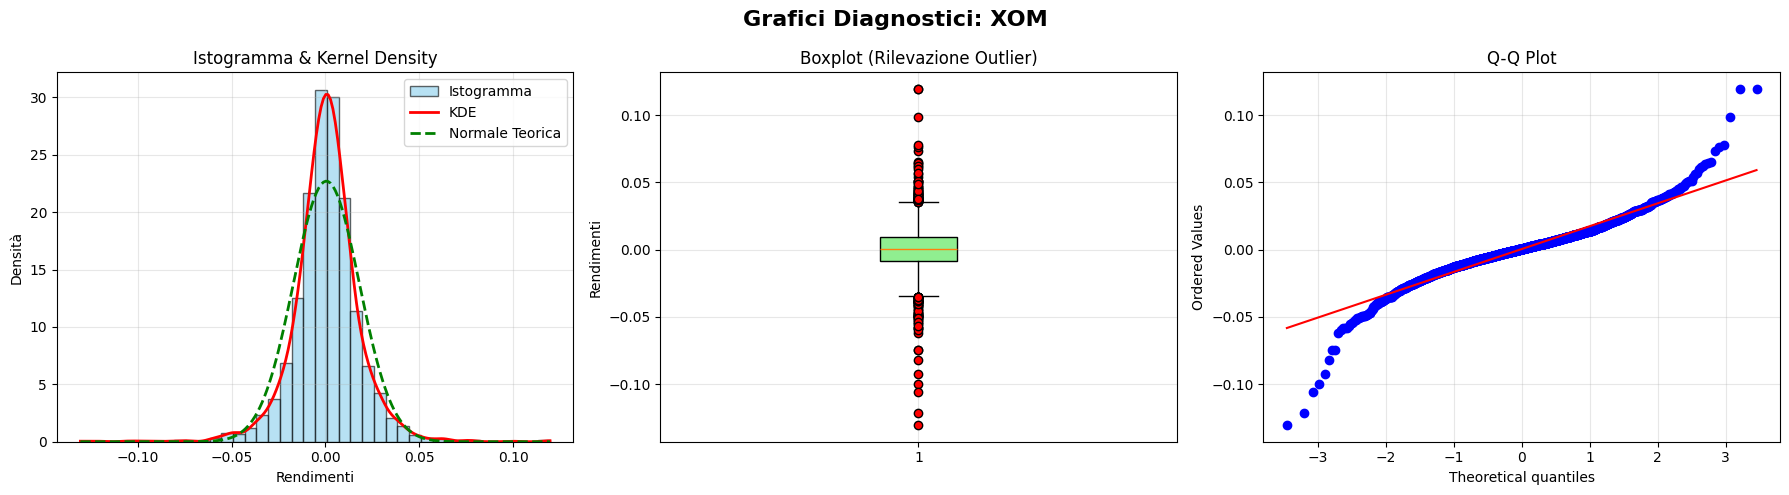

In [16]:
for ticker, df in stock_list:
    df_clean = df.dropna(subset=["LR"])
    # Creazione della figura con 3 sotto-grafici in linea
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(
        f"Grafici Diagnostici: {ticker}", fontsize=16, fontweight="bold"
    )

    # Sezione 1: Istogramma e Kernel Density (KDE)
    axes[0].hist(
        df_clean["LR"],
        bins=40,
        density=True,
        alpha=0.6,
        color="skyblue",
        edgecolor="black",
        label="Istogramma",
    )
    # Linea KDE
    kde = stats.gaussian_kde(df_clean["LR"])
    x_range = np.linspace(df_clean["LR"].min(), df_clean["LR"].max(), 200)
    axes[0].plot(x_range, kde(x_range), color="red", lw=2, label="KDE")
    # Linea Normale teorica per confronto
    mu, std = df_clean["LR"].mean(), df_clean["LR"].std()
    axes[0].plot(
        x_range,
        stats.norm.pdf(x_range, mu, std),
        color="green",
        linestyle="--",
        lw=2,
        label="Normale Teorica",
    )
    axes[0].set_title("Istogramma & Kernel Density")
    axes[0].set_xlabel("Rendimenti")
    axes[0].set_ylabel("Densità")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Sezione 2: Boxplot
    axes[1].boxplot(
        df_clean["LR"],
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor="lightgreen", color="black"),
        flierprops=dict(
            marker="o",
            markerfacecolor="red",
            markersize=6,
            linestyle="none",
        ),
    )
    axes[1].set_title("Boxplot (Rilevazione Outlier)")
    # axes[1].set_xticklabels(ticker)
    axes[1].set_ylabel("Rendimenti")
    axes[1].grid(True, alpha=0.3)

    # Sezione 3: Q-Q Plot
    stats.probplot(df_clean["LR"], dist="norm", plot=axes[2])
    axes[2].set_title("Q-Q Plot")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    # plt.savefig(f'./relazione/images/{ticker}_diagnostic_plots.png')
    plt.show()
    plt.close()

## Analisi univariata dei rendimenti
Analisi univariata dei rendimenti, con calcolo di media, varianza, deviazione standard, skewness e kurtosis (annualizzati).

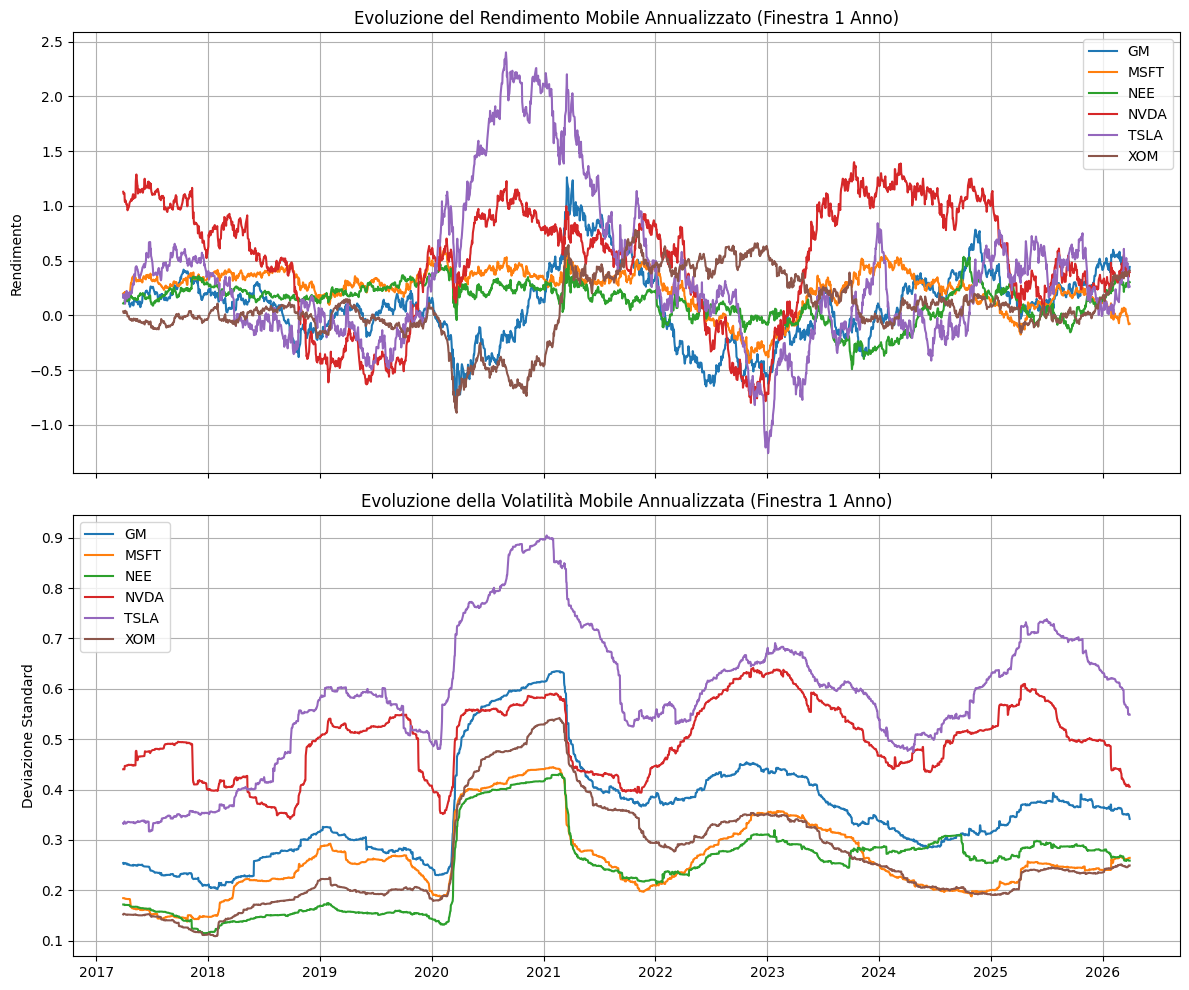

--- TABELLA DELLE STATISTICHE DESCRITTIVE ---


,Media Annualizzata,Varianza Annualizzata,Deviazione Standard Annualizzata,Asimmetria (Skewness),Curtosi in eccesso,Distanza da Normale
GM,0.104971,0.134598,0.366877,-0.060492,7.304753,7.305003
MSFT,0.200523,0.072286,0.268861,-0.260880,8.262421,8.266538
NEE,0.139415,0.064080,0.253141,-0.532199,9.570345,9.585132
NVDA,0.525829,0.245151,0.495127,0.100842,6.670914,6.671676
TSLA,0.315263,0.346177,0.588368,-0.046746,4.278325,4.278580
XOM,0.115734,0.077838,0.278995,-0.224439,6.496241,6.500117


In [17]:
report = {}
window_size = 252
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

for ticker, df in stock_list:
    df_clean = df.dropna(subset=["LR"])

    # Calcolo delle statistiche annualizzate complessive
    mean = df_clean["LR"].mean() * 252
    variance = df_clean["LR"].var() * 252
    std_dev = np.sqrt(variance)
    skewness = stats.skew(df_clean["LR"])
    kurtosis = stats.kurtosis(df_clean["LR"]) # Curtosi in eccesso (0 = Normale)

    # Calcolo della distanza geometrica dalla distribuzione Normale (0,0)
    dist_normale = np.sqrt(skewness**2 + kurtosis**2)

    report[ticker] = {
        "Media Annualizzata": mean,
        "Varianza Annualizzata": variance,
        "Deviazione Standard Annualizzata": std_dev,
        "Asimmetria (Skewness)": skewness,
        "Curtosi in eccesso": kurtosis,
        "Distanza da Normale": dist_normale
    }

    # Rendimento e volatilità mobile annualizzate
    df_clean["Rolling_Mean"] = df_clean["LR"].rolling(window=window_size).mean() * 252
    df_clean["Rolling_Vol"] = df_clean["LR"].rolling(window=window_size).std() * np.sqrt(252)

    # Grafico Rendimento e Volatilità nel tempo
    ax1.plot(df_clean.index, df_clean["Rolling_Mean"], label=ticker)
    ax2.plot(df_clean.index, df_clean["Rolling_Vol"], label=ticker)

# Finalizzazione dei grafici dell'evoluzione temporale
ax1.set_title("Evoluzione del Rendimento Mobile Annualizzato (Finestra 1 Anno)")
ax1.set_ylabel("Rendimento")
ax1.legend()
ax1.grid(True)

ax2.set_title("Evoluzione della Volatilità Mobile Annualizzata (Finestra 1 Anno)")
ax2.set_ylabel("Deviazione Standard")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
# plt.savefig(f'./relazione/images/moving_averages_volatility.png')
plt.show()

# Creazione DataFrame per la tabella delle statistiche descrittive
df_report = pd.DataFrame(report).T
print("--- TABELLA DELLE STATISTICHE DESCRITTIVE ---")
display(df_report)

## Correlazione tra rendimenti

Calcolo della matrice di varianze/covarianze e di correlazione dei rendimenti mensili dei titoli.

In [18]:
# Creazione DataFrame con i rendimenti logaritmici di tutti i titoli
df_lr = pd.DataFrame({ticker: df['LR'] for ticker, df in stock_list})
df_lr.dropna(inplace=True)

# Aggregazione mensile sommando i rendimenti logaritmici
df_m = df_lr.groupby(pd.Grouper(freq='ME')).sum()

# Calcolo matrice di Varianza/Covarianza dei rendimenti mensili
mat_cov = df_m.cov()

# Calcolo matrice di Correlazione dei rendimenti mensili
mat_corr = df_m.corr()

print("--- MATRICE DI VARIANZA/COVARIANZA MENSILE ---")
print(mat_cov)
print("\n--- MATRICE DI CORRELAZIONE MENSILE ---")
print(mat_corr)

--- MATRICE DI VARIANZA/COVARIANZA MENSILE ---
            GM      MSFT       NEE      NVDA      TSLA       XOM
GM    0.009170  0.001641  0.000784  0.005048  0.005782  0.003290
MSFT  0.001641  0.003570  0.000883  0.005087  0.004045  0.000234
NEE   0.000784  0.000883  0.003792  0.001371  0.001325 -0.000082
NVDA  0.005048  0.005087  0.001371  0.017741  0.007357  0.001206
TSLA  0.005782  0.004045  0.001325  0.007357  0.028481  0.000342
XOM   0.003290  0.000234 -0.000082  0.001206  0.000342  0.006382

--- MATRICE DI CORRELAZIONE MENSILE ---
            GM      MSFT       NEE      NVDA      TSLA       XOM
GM    1.000000  0.286772  0.132970  0.395760  0.357785  0.430044
MSFT  0.286772  1.000000  0.240033  0.639104  0.401102  0.049016
NEE   0.132970  0.240033  1.000000  0.167125  0.127509 -0.016583
NVDA  0.395760  0.639104  0.167125  1.000000  0.327287  0.113333
TSLA  0.357785  0.401102  0.127509  0.327287  1.000000  0.025395
XOM   0.430044  0.049016 -0.016583  0.113333  0.025395  1.000000


## Correlazione nel tempo

Creazione di scatter plot per visualizzare la relazione tra i rendimenti di coppie di titoli dello stesso settore.

In [19]:
# Creazione scatter plot con retta di regressione
def plot_scatter(x, y, color_scatter, title, xlabel, ylabel):    
    # Scatter plot
    plt.scatter(x, y, color=color_scatter, alpha=0.4, s=15, edgecolors='none')
    
    # Retta di regressione
    ## Calcolo dei coefficienti della retta (y = mx + q)
    m, q = np.polyfit(x, y, 1)
    ## Tracciamento della retta di tendenza lineare
    x_range = np.linspace(x.min(), x.max(), 100)
    plt.plot(x_range, m * x_range + q, color='red', linestyle='-', lw=2)
    
    plt.title(title, fontsize=11, fontweight='bold')
    plt.xlabel(xlabel, fontsize=9)
    plt.ylabel(ylabel, fontsize=9)
    plt.grid(True, linestyle=':', alpha=0.6)

    x_lims = plt.xlim()
    y_lims = plt.ylim()
    
    # 2. Trova il valore massimo assoluto tra tutti i limiti estratti
    max_val = max(abs(x_lims[0]), abs(x_lims[1]), abs(y_lims[0]), abs(y_lims[1]))
    
    # 3. Applica il valore massimo in modo simmetrico
    plt.xlim([-max_val, max_val])
    plt.ylim([-max_val, max_val])
    plt.gca().set_aspect('equal', adjustable='box')

    # plt.savefig(f'./relazione/images/{xlabel}_{ylabel}.png')
    plt.show()
    plt.close()

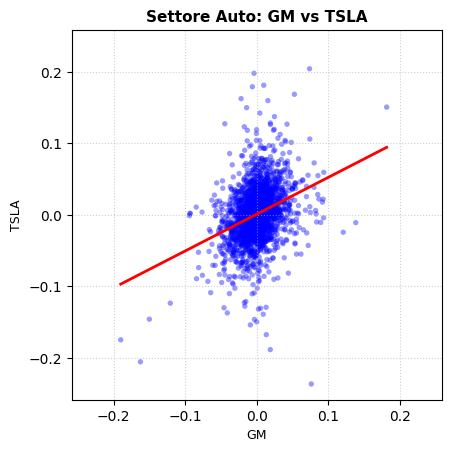

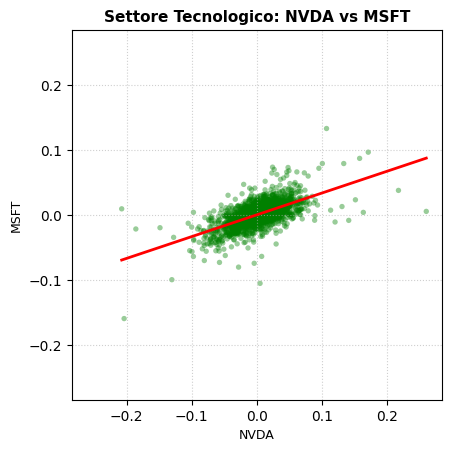

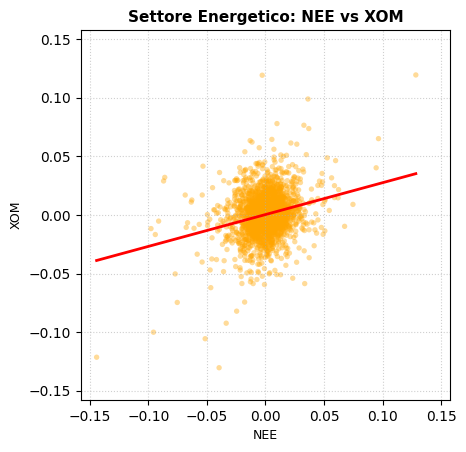

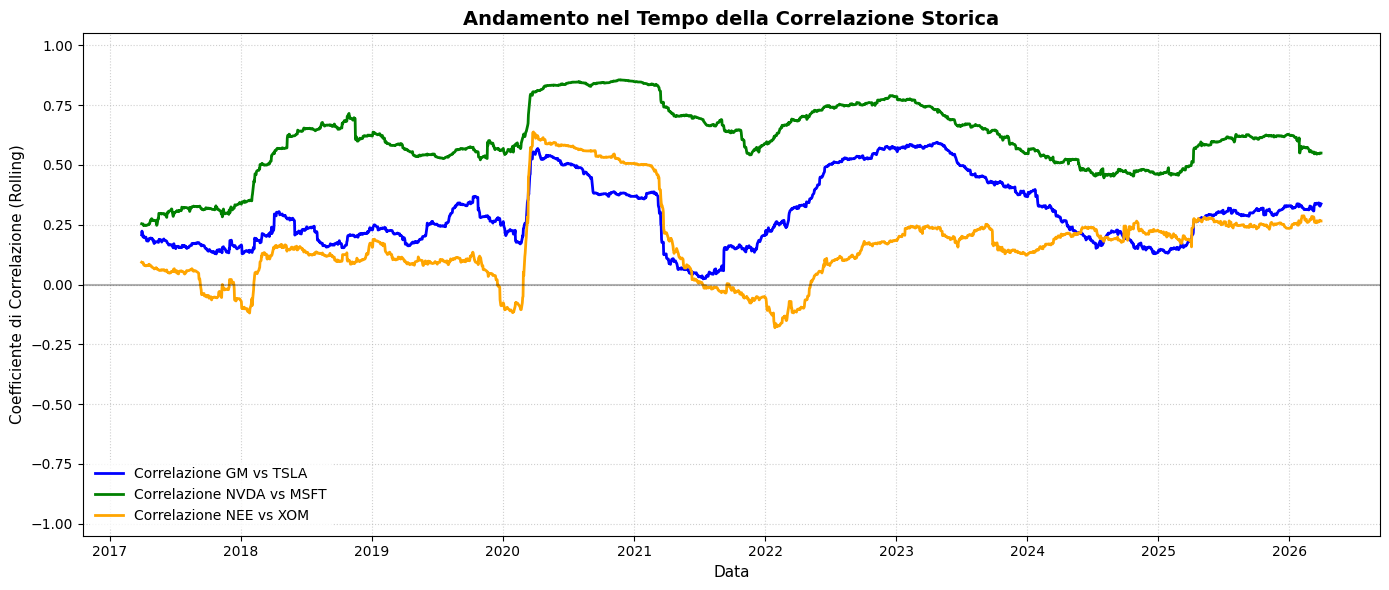

In [20]:
# Settore Auto: GM vs TSLA
plot_scatter(
    df_lr['GM'],
    df_lr['TSLA'], 
    'blue',
    'Settore Auto: GM vs TSLA',
    'GM',
    'TSLA'
)

# Settore Tech: NVDA vs MSFT
plot_scatter(
    df_lr['NVDA'], 
    df_lr['MSFT'], 
    'green', 
    'Settore Tecnologico: NVDA vs MSFT', 
    'NVDA', 
    'MSFT'
)

# Settore Energia: NEE vs XOM
plot_scatter(
    df_lr['NEE'], 
    df_lr['XOM'], 
    'orange', 
    'Settore Energetico: NEE vs XOM', 
    'NEE', 
    'XOM'
)

# Grafico della correlazione storica con finestra mobile
finestra_giorni = 252

rolling_auto = df_lr['GM'].rolling(window=finestra_giorni).corr(df_lr['TSLA'])
rolling_tech = df_lr['NVDA'].rolling(window=finestra_giorni).corr(df_lr['MSFT'])
rolling_energy = df_lr['NEE'].rolling(window=finestra_giorni).corr(df_lr['XOM'])

plt.figure(figsize=(14, 6))
plt.plot(rolling_auto, label='Correlazione GM vs TSLA', color='blue', lw=2)
plt.plot(rolling_tech, label='Correlazione NVDA vs MSFT', color='green', lw=2)
plt.plot(rolling_energy, label='Correlazione NEE vs XOM', color='orange', lw=2)

plt.title('Andamento nel Tempo della Correlazione Storica', fontsize=14, fontweight='bold')
plt.xlabel('Data', fontsize=11)
plt.ylabel('Coefficiente di Correlazione (Rolling)', fontsize=11)
plt.ylim(-1.05, 1.05)
plt.axhline(0, color='black', linestyle='-', alpha=0.3)
plt.legend(loc='lower left', frameon=True, facecolor='white', edgecolor='none')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
# plt.savefig(f'./relazione/images/rolling_correlation_same_sector3.png')
plt.show()
